# 05 - Court Homography Baseline

Obiettivo:
- selezionare manualmente punti corrispondenti tra un frame di basket e una mappa 2D del campo;
- calcolare una matrice di omografia;
- trasformare punti dall'immagine al piano del campo;
- verificare visivamente la correttezza della trasformazione.

Questa fase costituisce una baseline manuale.

L'automazione della court keypoint detection verrà affrontata successivamente.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [25]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
DRIVE_ROOT = Path("/content/drive/MyDrive/basketball-thesis")

SPORTSMOT_ROOT = Path(
    "/content/drive/MyDrive/basketball-thesis/datasets/sportsmot"
)

OUTPUT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "court_homography_baseline"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

SEQUENCE_DIR = (
    SPORTSMOT_ROOT
    / "val"
    / SEQUENCE_NAME
)

FRAMES_DIR = SEQUENCE_DIR / "img1"

print("Sequence:", SEQUENCE_DIR)
print("Frames:", FRAMES_DIR)

Sequence: /content/drive/MyDrive/basketball-thesis/datasets/sportsmot/val/v_00HRwkvvjtQ_c001
Frames: /content/drive/MyDrive/basketball-thesis/datasets/sportsmot/val/v_00HRwkvvjtQ_c001/img1


## Caricamento della sequenza e selezione del frame

In [27]:
import configparser

seqinfo_path = SEQUENCE_DIR / "seqinfo.ini"

config = configparser.ConfigParser()
config.read(seqinfo_path)

sequence_info = config["Sequence"]

fps = int(sequence_info["frameRate"])
width = int(sequence_info["imWidth"])
height = int(sequence_info["imHeight"])
seq_length = int(sequence_info["seqLength"])

print("FPS:", fps)
print("Resolution:", width, "x", height)
print("Frames:", seq_length)

FPS: 25
Resolution: 1280 x 720
Frames: 1162


In [28]:
frames = [
    FRAMES_DIR / f"{i:06d}.jpg"
    for i in range(1, seq_length + 1)
]

missing_frames = [
    f for f in frames
    if not f.exists()
]

print("Frame attesi:", len(frames))
print("Frame mancanti:", len(missing_frames))

assert len(missing_frames) == 0

print("Numero frame:", len(frames))

FRAME_NUMBER = 100

frame_path = frames[FRAME_NUMBER - 1]

frame_bgr = cv2.imread(str(frame_path))

assert frame_bgr is not None, (
    f"Impossibile leggere il frame: {frame_path}"
)

frame_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB,
)

print("Frame:", frame_path.name)
print("Shape:", frame_rgb.shape)

Frame attesi: 1162
Frame mancanti: 0
Numero frame: 1162
Frame: 000100.jpg
Shape: (720, 1280, 3)


## Visualizzazione del frame selezionato

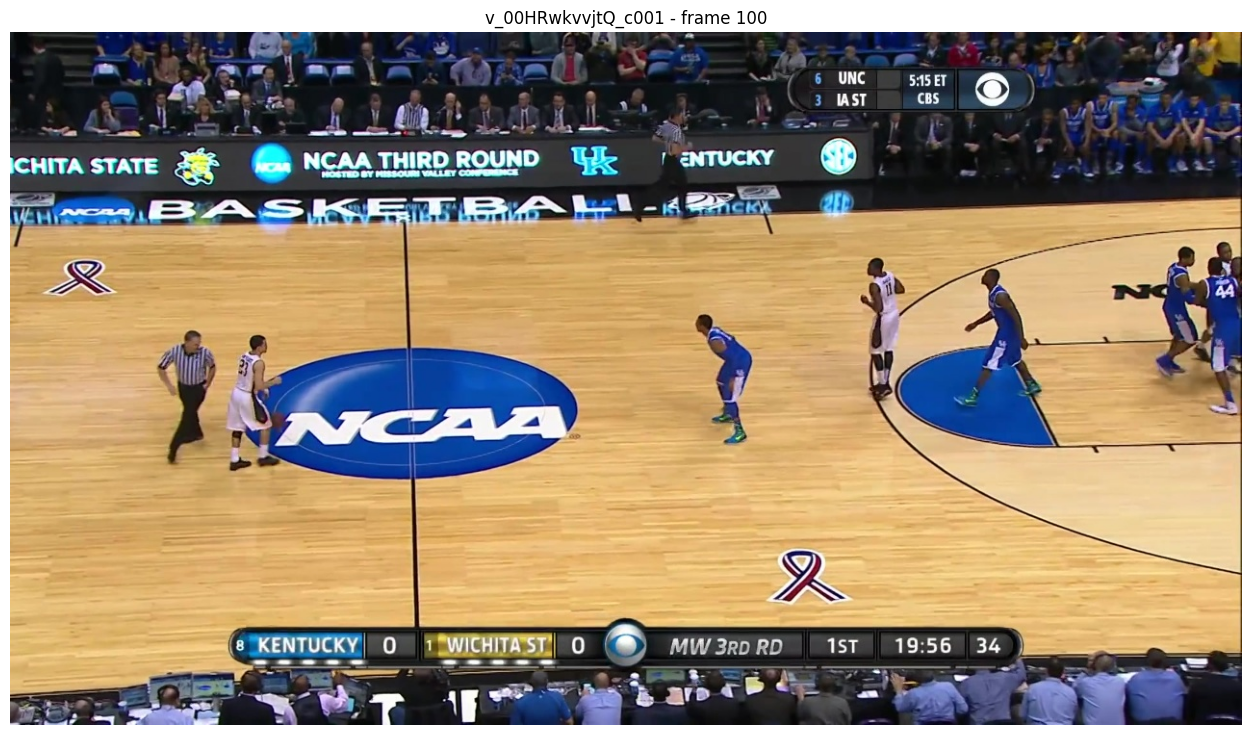

In [29]:
plt.figure(figsize=(16, 9))

plt.imshow(frame_rgb)

plt.title(
    f"{SEQUENCE_NAME} - frame {FRAME_NUMBER}"
)

plt.axis("off")
plt.show()

## Mappa del campo

In [30]:
COURT_LENGTH = 28.6512   # metri
COURT_WIDTH = 15.24      # metri

print(
    f"Campo: {COURT_LENGTH} m x {COURT_WIDTH} m"
)

Campo: 28.6512 m x 15.24 m


## Sistema di coordinate del campo NCAA

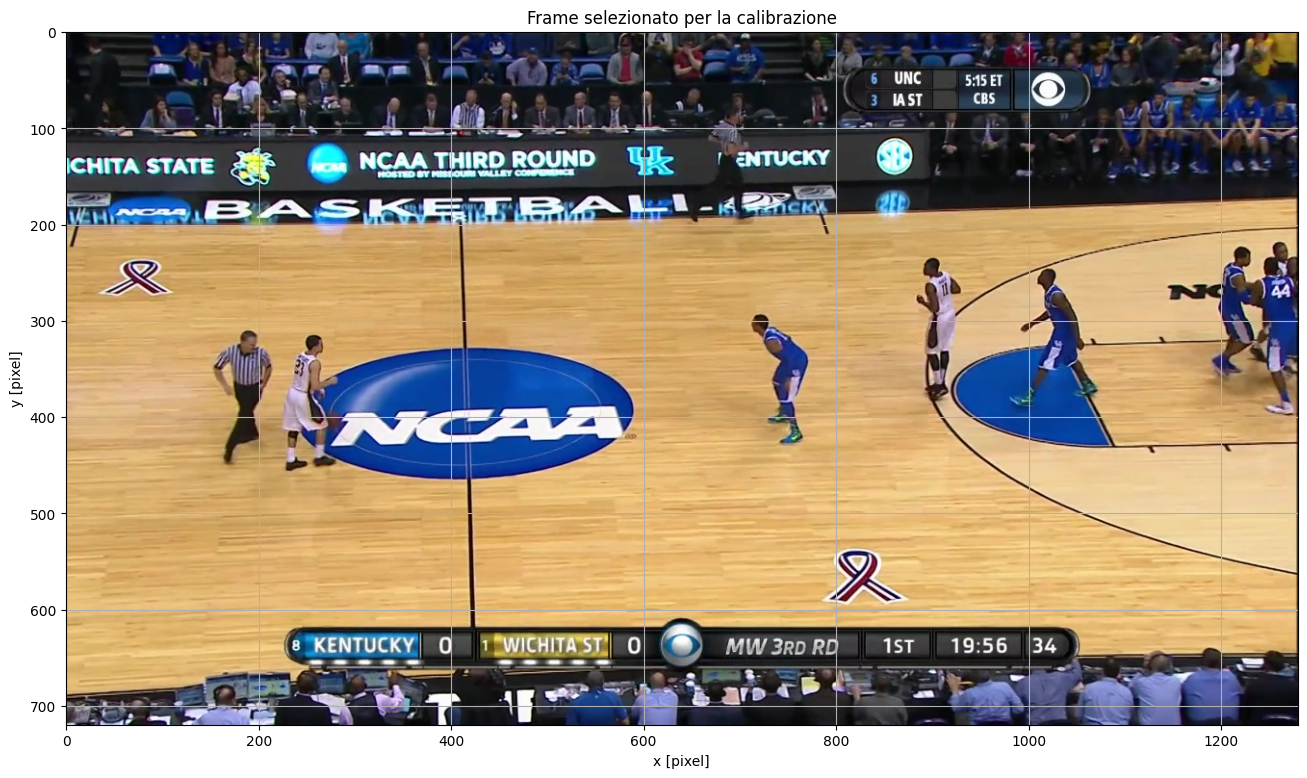

In [31]:
%matplotlib inline

plt.figure(figsize=(16, 9))
plt.imshow(frame_rgb)
plt.title("Frame selezionato per la calibrazione")
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.grid()

plt.show()

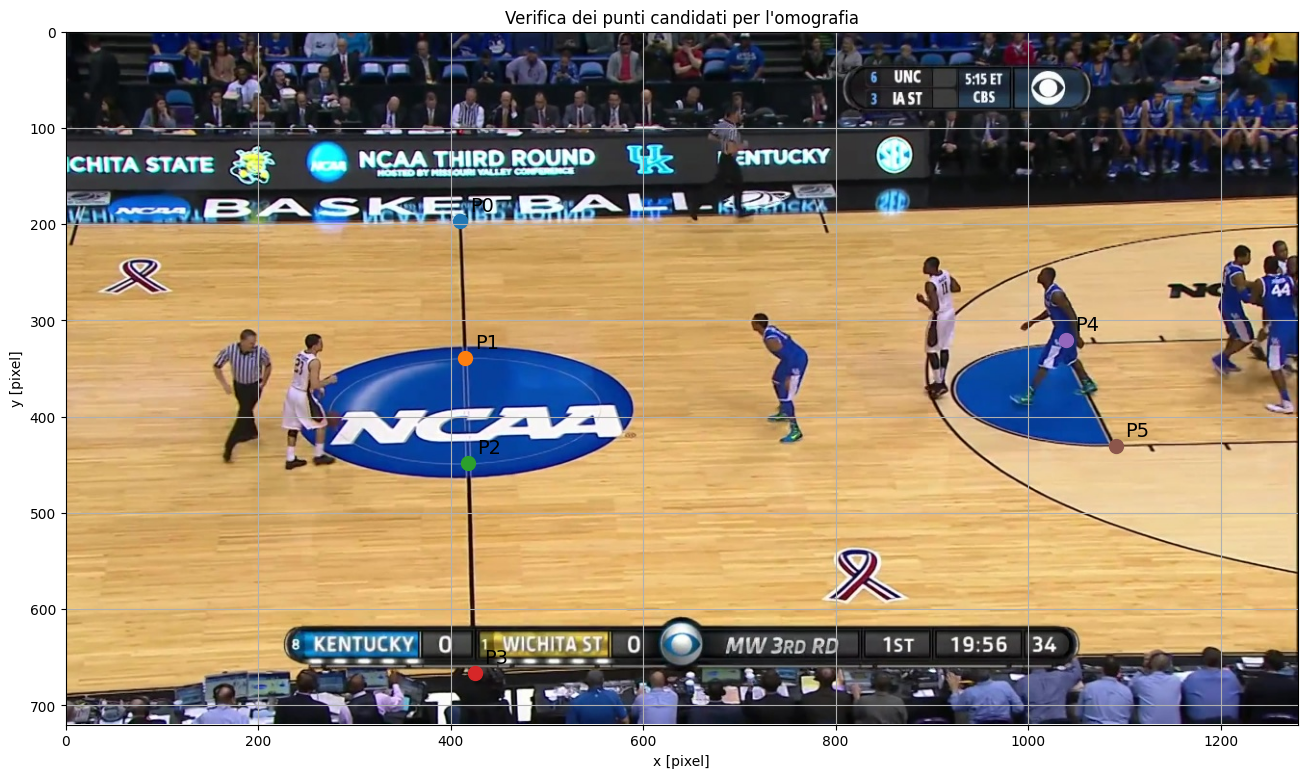

In [61]:
candidate_image_points = np.array([
    [410, 197],   # P0 - metà campo / sideline superiore
    [415, 339],   # P1 - metà campo / cerchio centrale superiore
    [418, 448],   # P2 - metà campo / cerchio centrale inferiore
    [425, 666],   # P3 - metà campo / sideline inferiore
    [1039, 320],  # P4 - free throw line / lane superiore
    [1091, 430],  # P5 - free throw line / lane inferiore
], dtype=np.float32)

plt.figure(figsize=(16, 9))
plt.imshow(frame_rgb)

for i, (x, y) in enumerate(candidate_image_points):
    plt.scatter(x, y, s=100)
    plt.text(
        x + 10,
        y - 10,
        f"P{i}",
        fontsize=14
    )

plt.xlim(0, frame_rgb.shape[1])
plt.ylim(frame_rgb.shape[0], 0)

plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.title("Verifica dei punti candidati per l'omografia")
plt.grid()
plt.show()

In [62]:
FT_TO_M = 0.3048

image_points = candidate_image_points.copy()

court_points_ft = np.array([
    [47.0,  0.0],   # P0 - metà campo / sideline superiore
    [47.0, 19.0],   # P1 - metà campo / cerchio centrale superiore
    [47.0, 31.0],   # P2 - metà campo / cerchio centrale inferiore
    [47.0, 50.0],   # P3 - metà campo / sideline inferiore
    [75.0, 19.0],   # P4 - free throw line / lane superiore
    [75.0, 31.0],   # P5 - free throw line / lane inferiore
], dtype=np.float32)

court_points = (
    court_points_ft * FT_TO_M
)

print("Image points:")
print(image_points)

print("\nCourt points [m]:")
print(court_points)

Image points:
[[ 410.  197.]
 [ 415.  339.]
 [ 418.  448.]
 [ 425.  666.]
 [1039.  320.]
 [1091.  430.]]

Court points [m]:
[[14.325601  0.      ]
 [14.325601  5.7912  ]
 [14.325601  9.4488  ]
 [14.325601 15.24    ]
 [22.86      5.7912  ]
 [22.86      9.4488  ]]


In [63]:
H, mask = cv2.findHomography(
    image_points,
    court_points,
    method=cv2.RANSAC,
    ransacReprojThreshold=0.9
)

assert H is not None, (
    "Impossibile stimare la matrice di omografia."
)

print("Homography matrix H:")
print(H)

print("\nRANSAC inlier mask:")
print(mask.ravel())

Homography matrix H:
[[ 2.04808010e-02  1.48297833e-02  6.45205375e+00]
 [ 1.95903487e-03  5.67150834e-02 -1.19672047e+01]
 [ 7.18827304e-05  1.07521992e-03  1.00000000e+00]]

RANSAC inlier mask:
[1 1 1 1 1 1]


In [64]:
projected_points = cv2.perspectiveTransform(
    image_points.reshape(-1, 1, 2),
    H
).reshape(-1, 2)

errors = np.linalg.norm(
    projected_points - court_points,
    axis=1
)

for i, (pred, gt, err) in enumerate(
    zip(projected_points, court_points, errors)
):
    print(
        f"P{i}: "
        f"pred={pred.round(3)} "
        f"target={gt.round(3)} "
        f"error={err:.3f} m"
    )

mean_reprojection_error = errors.mean()

print(
    "\nMean reprojection error:",
    f"{mean_reprojection_error:.3f} m"
)

P0: pred=[1.4316e+01 7.0000e-03] target=[14.326  0.   ] error=0.012 m
P1: pred=[14.329  5.789] target=[14.326  5.791] error=0.004 m
P2: pred=[14.326  9.433] target=[14.326  9.449] error=0.016 m
P3: pred=[14.332 15.251] target=[14.326 15.24 ] error=0.013 m
P4: pred=[22.891  5.792] target=[22.86   5.791] error=0.031 m
P5: pred=[22.828  9.448] target=[22.86   9.449] error=0.032 m

Mean reprojection error: 0.018 m


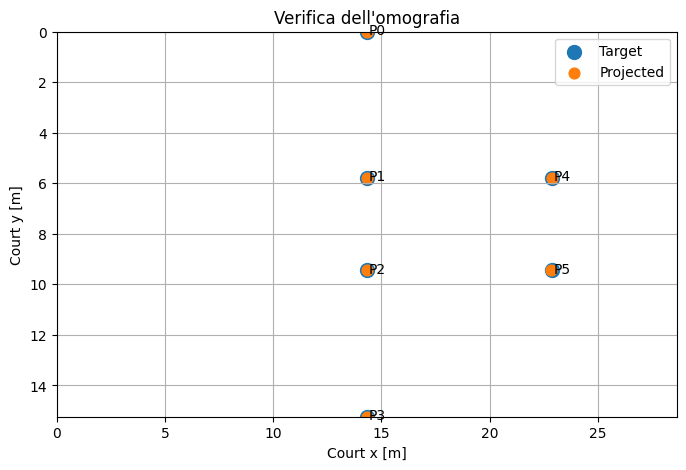

In [65]:
plt.figure(figsize=(8, 5))

plt.scatter(
    court_points[:, 0],
    court_points[:, 1],
    s=100,
    label="Target"
)

plt.scatter(
    projected_points[:, 0],
    projected_points[:, 1],
    s=60,
    label="Projected"
)

for i in range(len(court_points)):
    plt.text(
        court_points[i, 0] + 0.1,
        court_points[i, 1] + 0.1,
        f"P{i}"
    )

plt.xlim(0, COURT_LENGTH)
plt.ylim(COURT_WIDTH, 0)

plt.xlabel("Court x [m]")
plt.ylabel("Court y [m]")

plt.title("Verifica dell'omografia")

plt.legend()
plt.grid()
plt.show()

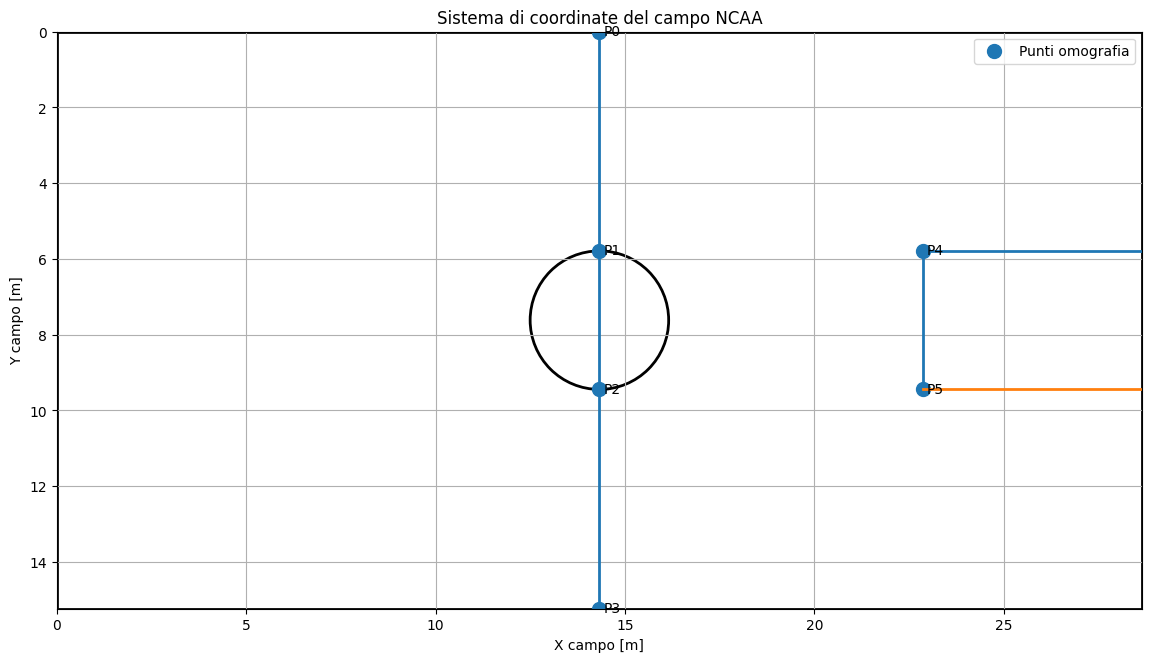

In [72]:
fig, ax = plt.subplots(
    figsize=(14, 7.5)
)

# Limiti del campo
ax.set_xlim(
    0,
    COURT_LENGTH,
)

ax.set_ylim(
    COURT_WIDTH,
    0,
)

ax.set_aspect("equal")

ax.set_xlabel("X campo [m]")
ax.set_ylabel("Y campo [m]")

ax.set_title("Sistema di coordinate del campo NCAA")

# Bordo esterno del campo
court_border = plt.Rectangle(
    (0, 0),
    COURT_LENGTH,
    COURT_WIDTH,
    fill=False,
    linewidth=2
)

ax.add_patch(court_border)

# Linea di metà campo
ax.axvline(
    COURT_LENGTH / 2,
    linewidth=2
)

# Centro del campo
center_x = COURT_LENGTH / 2
center_y = COURT_WIDTH / 2

# Cerchio centrale
CENTER_CIRCLE_RADIUS = 6 * 0.3048  # 6 ft in metri

center_circle = plt.Circle(
    (center_x, center_y),
    CENTER_CIRCLE_RADIUS,
    fill=False,
    linewidth=2
)

ax.add_patch(center_circle)

# Linea di tiro libero destra
FREE_THROW_X_RIGHT = 75 * 0.3048

ax.axvline(
    FREE_THROW_X_RIGHT,
    ymin=(19 * 0.3048) / COURT_WIDTH,
    ymax=(31 * 0.3048) / COURT_WIDTH,
    linewidth=2
)

# Lane destra
lane_y_top = 19 * 0.3048
lane_y_bottom = 31 * 0.3048

ax.plot(
    [FREE_THROW_X_RIGHT, COURT_LENGTH],
    [lane_y_top, lane_y_top],
    linewidth=2
)

ax.plot(
    [FREE_THROW_X_RIGHT, COURT_LENGTH],
    [lane_y_bottom, lane_y_bottom],
    linewidth=2
)

# Punti utilizzati per l'omografia
ax.scatter(
    court_points[:, 0],
    court_points[:, 1],
    s=100,
    label="Punti omografia"
)

for i, (x, y) in enumerate(court_points):
    ax.text(
        x + 0.1,
        y + 0.1,
        f"P{i}"
    )

ax.legend()
ax.grid(True)

plt.show()

## Funzione di trasformazione immagine → campo

In [73]:
def image_to_court(point_xy, H):

    point = np.array(
        [[[point_xy[0], point_xy[1]]]],
        dtype=np.float32,
    )

    transformed = cv2.perspectiveTransform(
        point,
        H,
    )

    x, y = transformed[0][0]

    return float(x), float(y)

## Verifica sui punti utilizzati per l'omografia

In [74]:
for i, point in enumerate(image_points):

    projected = image_to_court(
        point,
        H,
    )

    print(
        f"P{i}",
        "expected:",
        court_points[i],
        "projected:",
        projected,
    )

P0 expected: [14.325601  0.      ] projected: (14.316272735595703, 0.007146643474698067)
P1 expected: [14.325601  5.7912  ] projected: (14.328652381896973, 5.789306163787842)
P2 expected: [14.325601  9.4488  ] projected: (14.32567310333252, 9.43282413482666)
P3 expected: [14.325601 15.24    ] projected: (14.332051277160645, 15.250726699829102)
P4 expected: [22.86    5.7912] projected: (22.891267776489258, 5.791733264923096)
P5 expected: [22.86    9.4488] projected: (22.8284854888916, 9.448264122009277)


## Proiezione della posizione del giocatore

Per collegare il tracking alla localizzazione sul campo, la posizione del giocatore viene rappresentata inizialmente tramite il punto bottom-center della bounding box.

Il centro geometrico della bounding box non rappresenta infatti il punto di contatto del giocatore con il parquet.

Il punto bottom-center è definito come:

x = (x1 + x2) / 2  
y = y2

Questa scelta fornisce una prima approssimazione della posizione del giocatore sul piano del campo.

### Funzione bottom-center

In [75]:
def bbox_bottom_center(
    x1,
    y1,
    x2,
    y2,
):

    x = (x1 + x2) / 2
    y = y2

    return float(x), float(y)

## Test su una bounding box reale prodotta da ByteTrack

In [80]:
TRACKING_CSV = (
    DRIVE_ROOT
    / "experiments"
    / "bytetrack_baseline"
    / f"{SEQUENCE_NAME}_tracks.csv"
)

print("Tracking CSV:")
print(TRACKING_CSV)

print(
    "Exists:",
    TRACKING_CSV.exists()
)

Tracking CSV:
/content/drive/MyDrive/basketball-thesis/experiments/bytetrack_baseline/v_00HRwkvvjtQ_c001_tracks.csv
Exists: True


### Visualizzazione della bounding box e del punto bottom-center

In [82]:
tracks_df = pd.read_csv(
    TRACKING_CSV
)

frame_tracks = tracks_df[
    tracks_df["frame"] == FRAME_NUMBER
].copy()

print(
    "Track presenti nel frame:",
    len(frame_tracks)
)

display(
    frame_tracks.head()
)

Track presenti nel frame: 7


,frame,time,track_id,confidence,x1,y1,x2,y2
815,100,3.96,0,0.864829,883.371277,233.001526,930.412476,393.307251
816,100,3.96,1,0.832265,1232.289551,218.367126,1279.708008,397.879700
817,100,3.96,4,0.898626,711.084900,291.930817,772.940369,429.355713
818,100,3.96,6,0.906648,982.764221,242.707108,1073.939087,391.007721
819,100,3.96,8,0.869538,225.371368,313.286682,282.256531,456.654633


In [83]:
assert not frame_tracks.empty, (
    f"Nessuna track trovata nel frame {FRAME_NUMBER}"
)

example_track = frame_tracks.iloc[0]

bbox = (
    float(example_track["x1"]),
    float(example_track["y1"]),
    float(example_track["x2"]),
    float(example_track["y2"]),
)

track_id = int(
    example_track["track_id"]
)

player_pixel = bbox_bottom_center(
    *bbox
)

player_court = image_to_court(
    player_pixel,
    H,
)

print("Track ID:", track_id)
print("BBox:", bbox)
print("Bottom-center:", player_pixel)
print("Posizione campo [m]:", player_court)

Track ID: 0
BBox: (883.3712768554688, 233.00152587890625, 930.4124755859376, 393.3072509765625)
Bottom-center: (906.8918762207031, 393.3072509765625)
Posizione campo [m]: (20.737159729003906, 8.141946792602539)


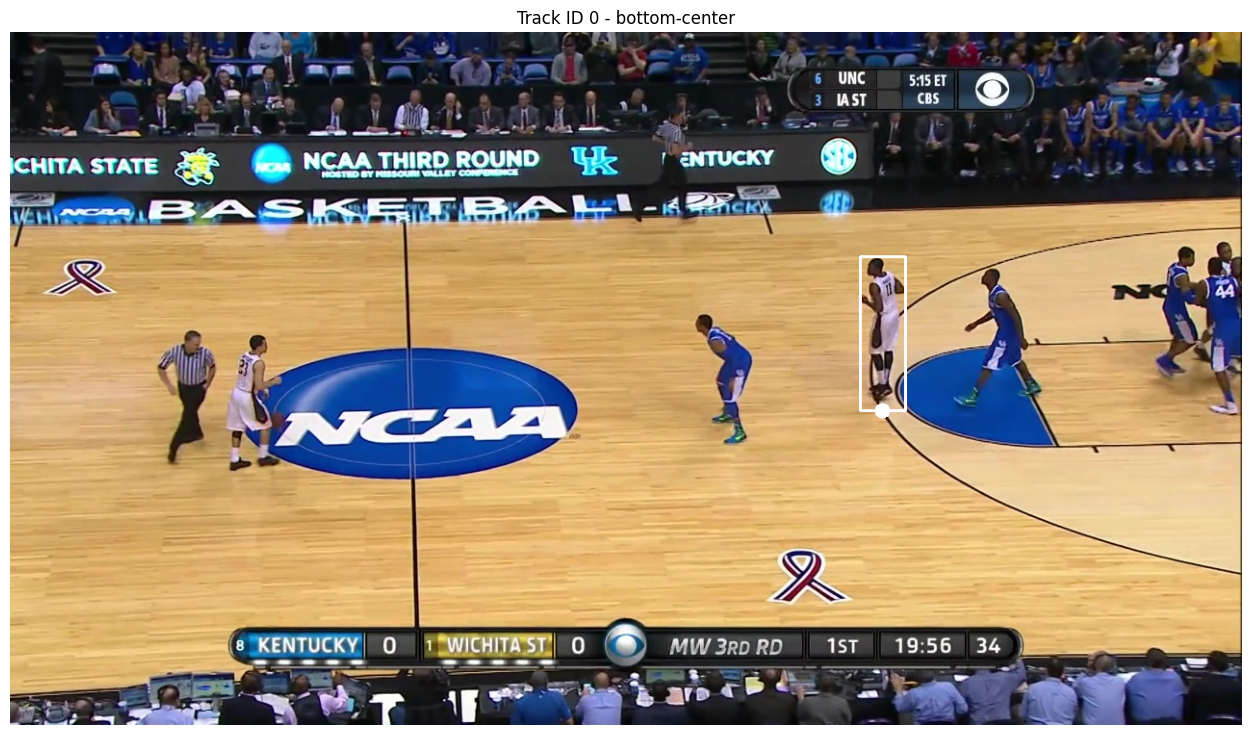

In [84]:
x1, y1, x2, y2 = bbox

image_test = frame_bgr.copy()

cv2.rectangle(
    image_test,
    (int(x1), int(y1)),
    (int(x2), int(y2)),
    (255, 255, 255),
    2,
)

cv2.circle(
    image_test,
    (
        int(player_pixel[0]),
        int(player_pixel[1]),
    ),
    8,
    (255, 255, 255),
    -1,
)

plt.figure(figsize=(16, 9))

plt.imshow(
    cv2.cvtColor(
        image_test,
        cv2.COLOR_BGR2RGB,
    )
)

plt.title(
    f"Track ID {track_id} - bottom-center"
)

plt.axis("off")
plt.show()

## Salvataggio dell'omografia

### Salvataggio della matrice H

In [85]:
H_PATH = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_homography.npy"
)

np.save(
    H_PATH,
    H,
)

print(
    "Homography salvata:",
    H_PATH,
)

Homography salvata: /content/drive/MyDrive/basketball-thesis/experiments/court_homography_baseline/v_00HRwkvvjtQ_c001_homography.npy


### Salvataggio dei punti di calibrazione

In [86]:
POINTS_PATH = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_points.npz"
)

np.savez(
    POINTS_PATH,
    image_points=image_points,
    court_points=court_points,
    frame_number=FRAME_NUMBER,
    court_length=COURT_LENGTH,
    court_width=COURT_WIDTH,
    unit="meters",
)

print(
    "Punti salvati:",
    POINTS_PATH,
)

Punti salvati: /content/drive/MyDrive/basketball-thesis/experiments/court_homography_baseline/v_00HRwkvvjtQ_c001_points.npz


### Ricaricamento di controllo

In [87]:
H_loaded = np.load(
    H_PATH
)

points_loaded = np.load(
    POINTS_PATH,
    allow_pickle=True,
)

print("H:")
print(H_loaded)

print()

print(
    "Image points:",
    points_loaded["image_points"],
)

print()

print(
    "Court points:",
    points_loaded["court_points"],
)

print()

print(
    "Frame:",
    int(points_loaded["frame_number"])
)

print(
    "Unit:",
    points_loaded["unit"]
)

H:
[[ 2.04808010e-02  1.48297833e-02  6.45205375e+00]
 [ 1.95903487e-03  5.67150834e-02 -1.19672047e+01]
 [ 7.18827304e-05  1.07521992e-03  1.00000000e+00]]

Image points: [[ 410.  197.]
 [ 415.  339.]
 [ 418.  448.]
 [ 425.  666.]
 [1039.  320.]
 [1091.  430.]]

Court points: [[14.325601  0.      ]
 [14.325601  5.7912  ]
 [14.325601  9.4488  ]
 [14.325601 15.24    ]
 [22.86      5.7912  ]
 [22.86      9.4488  ]]

Frame: 100
Unit: meters


# Risultati baseline omografia

La baseline di court localization è stata costruita utilizzando una selezione manuale di punti geometricamente riconoscibili sul campo.

La sequenza analizzata è:

`v_00HRwkvvjtQ_c001`

La calibrazione è stata effettuata sul frame:

`100`

## Configurazione

Sono stati utilizzati 6 punti di corrispondenza tra immagine e campo.

Le coordinate del campo sono espresse in metri e fanno riferimento alle dimensioni standard NCAA:

- lunghezza: 28.6512 m;
- larghezza: 15.24 m.

La matrice di omografia è stata stimata tramite `cv2.findHomography()` utilizzando RANSAC.

## Valutazione della calibrazione

Per verificare la qualità della trasformazione, i punti immagine utilizzati per la calibrazione sono stati riproiettati sul piano del campo.

La qualità viene valutata tramite:

- errore di riproiezione per ciascun punto;
- errore medio di riproiezione;
- RANSAC inlier mask.

I risultati ottenuti sono:

- Mean reprojection error: 0.018 m;
- Numero di inlier RANSAC: 6;
- Numero totale di punti: 6.

Tutti i punti utilizzati per la calibrazione sono stati classificati come inlier da RANSAC.

L'errore medio di riproiezione risulta pari a circa 1.8 cm sui punti utilizzati per la stima dell'omografia.

Questo valore indica una forte coerenza interna tra le corrispondenze immagine-campo selezionate manualmente.

È necessario sottolineare che l'errore di riproiezione viene calcolato sugli stessi punti utilizzati per stimare l'omografia.

Di conseguenza, tale valore misura principalmente la coerenza interna della calibrazione e non costituisce da solo una misura indipendente della capacità di generalizzazione geometrica della trasformazione.

Una valutazione più rigorosa potrà essere effettuata introducendo ulteriori punti di controllo non utilizzati durante la stima della matrice H.

## Collegamento con il tracking

La matrice di omografia viene applicata al punto bottom-center delle bounding box prodotte dalla pipeline RF-DETR + ByteTrack.

La trasformazione consente di passare da:

pixel immagine → coordinate metriche sul campo.

Questo rappresenta il collegamento tra la fase di tracking temporale e la successiva ricostruzione delle traiettorie dei giocatori.

## Limiti

La calibrazione attuale è manuale e viene calcolata su un singolo frame.

La matrice di omografia rimane valida soltanto finché la geometria della camera rispetto al campo non cambia in maniera significativa.

Movimenti della telecamera, pan, zoom o cambi di inquadratura possono rendere necessaria una nuova stima dell'omografia.

Una fase successiva potrà quindi valutare:

- court keypoint detection automatica;
- aggiornamento dinamico dell'omografia;
- propagazione dell'errore di calibrazione sulle coordinate dei giocatori.